In [1]:
pip install ucimlrepo

In [2]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo

In [3]:
# fetch dataset
wine_quality = fetch_ucirepo(id=186)
X = wine_quality.data.features
y = wine_quality.data.targets

In [4]:
print(X.shape)
print(y.shape)

(6497, 11)
(6497, 1)


In [5]:
X = torch.tensor(X.values, dtype=torch.float32)

le = LabelEncoder()
y_encoded = le.fit_transform(y.values.ravel())

y_binary = (y_encoded != 0).astype(int)
y = torch.tensor(y_binary, dtype=torch.float32)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

torch.Size([5197, 11])
torch.Size([5197])
torch.Size([1300, 11])
torch.Size([1300])


In [20]:
model = nn.Sequential(
    nn.Linear(11, 22),
    nn.ReLU(),
    nn.Linear(22, 35),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(35,1), # Changed output features to 1 for binary classification
    nn.Sigmoid()
)
print(model)

Sequential(
  (0): Linear(in_features=11, out_features=22, bias=True)
  (1): ReLU()
  (2): Linear(in_features=22, out_features=35, bias=True)
  (3): ReLU()
  (4): Dropout(p=0.5, inplace=False)
  (5): Linear(in_features=35, out_features=1, bias=True)
  (6): Sigmoid()
)


In [21]:
Optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()
epochs = 20

In [22]:
loss=[]
for epoch in range(epochs):
  Optimizer.zero_grad()
  y_pred = model(X_train)
  accuracy_train = accuracy_score(y_train.detach().numpy(), y_pred.round().detach().numpy())
  current_loss = criterion(y_pred, y_train.unsqueeze(1))
  loss.append(current_loss.item())
  current_loss.backward()
  Optimizer.step()
  print(f"Epoch {epoch+1}/{epochs}, Loss: {current_loss.item():.4f}, Accuracy: {accuracy_train:.4f}")

Epoch 1/20, Loss: 0.3955, Accuracy: 0.8617
Epoch 2/20, Loss: 0.3236, Accuracy: 0.8811
Epoch 3/20, Loss: 0.2781, Accuracy: 0.9026
Epoch 4/20, Loss: 0.2366, Accuracy: 0.9228
Epoch 5/20, Loss: 0.2497, Accuracy: 0.9311
Epoch 6/20, Loss: 0.2178, Accuracy: 0.9380
Epoch 7/20, Loss: 0.1800, Accuracy: 0.9538
Epoch 8/20, Loss: 0.1818, Accuracy: 0.9631
Epoch 9/20, Loss: 0.1586, Accuracy: 0.9708
Epoch 10/20, Loss: 0.1623, Accuracy: 0.9727
Epoch 11/20, Loss: 0.1736, Accuracy: 0.9775
Epoch 12/20, Loss: 0.1484, Accuracy: 0.9804
Epoch 13/20, Loss: 0.2044, Accuracy: 0.9852
Epoch 14/20, Loss: 0.1786, Accuracy: 0.9877
Epoch 15/20, Loss: 0.1442, Accuracy: 0.9879
Epoch 16/20, Loss: 0.1514, Accuracy: 0.9913
Epoch 17/20, Loss: 0.1411, Accuracy: 0.9883
Epoch 18/20, Loss: 0.1682, Accuracy: 0.9911
Epoch 19/20, Loss: 0.1681, Accuracy: 0.9917
Epoch 20/20, Loss: 0.1339, Accuracy: 0.9927


Text(0, 0.5, 'Loss')

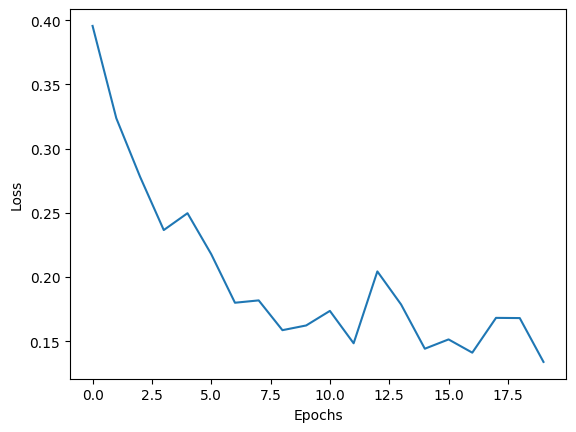

In [23]:
#plot the loss
import matplotlib.pyplot as plt
plt.plot(loss)
plt.xlabel('Epochs')
plt.ylabel('Loss')

In [24]:
model.eval()
with torch.no_grad():
  for epoch in range(20):
    y_pred_test = model(X_test)
    accuracy_test = accuracy_score(y_test.detach().numpy(), y_pred_test.round().detach().numpy())
    loss_test = criterion(y_pred_test, y_test.unsqueeze(1)) # Calculate loss on test set
    print(f"Epoch {epoch+1}/{epochs}, Test Loss: {loss_test.item():.4f}, Test Accuracy: {accuracy_test:.4f}")
model.train() # Set the model back to training mode

Epoch 1/20, Test Loss: 0.2576, Test Accuracy: 0.9954
Epoch 2/20, Test Loss: 0.2576, Test Accuracy: 0.9954
Epoch 3/20, Test Loss: 0.2576, Test Accuracy: 0.9954
Epoch 4/20, Test Loss: 0.2576, Test Accuracy: 0.9954
Epoch 5/20, Test Loss: 0.2576, Test Accuracy: 0.9954
Epoch 6/20, Test Loss: 0.2576, Test Accuracy: 0.9954
Epoch 7/20, Test Loss: 0.2576, Test Accuracy: 0.9954
Epoch 8/20, Test Loss: 0.2576, Test Accuracy: 0.9954
Epoch 9/20, Test Loss: 0.2576, Test Accuracy: 0.9954
Epoch 10/20, Test Loss: 0.2576, Test Accuracy: 0.9954
Epoch 11/20, Test Loss: 0.2576, Test Accuracy: 0.9954
Epoch 12/20, Test Loss: 0.2576, Test Accuracy: 0.9954
Epoch 13/20, Test Loss: 0.2576, Test Accuracy: 0.9954
Epoch 14/20, Test Loss: 0.2576, Test Accuracy: 0.9954
Epoch 15/20, Test Loss: 0.2576, Test Accuracy: 0.9954
Epoch 16/20, Test Loss: 0.2576, Test Accuracy: 0.9954
Epoch 17/20, Test Loss: 0.2576, Test Accuracy: 0.9954
Epoch 18/20, Test Loss: 0.2576, Test Accuracy: 0.9954
Epoch 19/20, Test Loss: 0.2576, Test 

Sequential(
  (0): Linear(in_features=11, out_features=22, bias=True)
  (1): ReLU()
  (2): Linear(in_features=22, out_features=35, bias=True)
  (3): ReLU()
  (4): Dropout(p=0.5, inplace=False)
  (5): Linear(in_features=35, out_features=1, bias=True)
  (6): Sigmoid()
)